In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#!pip install xgboost

In [3]:
import xgboost

In [4]:
df=pd.read_csv("airlines_flights_data.csv")

In [5]:
df=df.drop(columns=['index','flight'])

In [6]:
df

,airline,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...
300148,Vistara,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,Vistara,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,Vistara,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,Vistara,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585


In [7]:
df['airline'].value_counts()

airline
Vistara      127859
Air_India     80892
Indigo        43120
GO_FIRST      23173
AirAsia       16098
SpiceJet       9011
Name: count, dtype: int64

<Axes: xlabel='airline'>

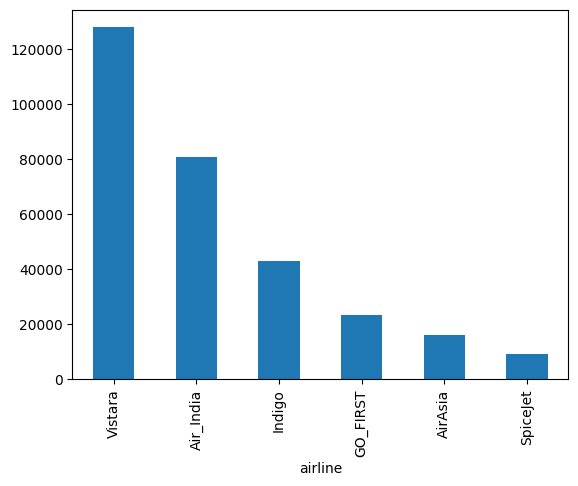

In [8]:
df['airline'].value_counts().plot(kind='bar')

In [9]:
df.isnull().sum()

airline             0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64

In [10]:
departure_time=df['departure_time'].value_counts().reset_index()
arrival_time=df['arrival_time'].value_counts().reset_index()

In [11]:
departure_time.columns=['departure','DCounts']
arrival_time.columns=['arrival','ACounts']

In [12]:
arrival_time

,arrival,ACounts
0,Night,91538
1,Evening,78323
2,Morning,62735
3,Afternoon,38139
4,Early_Morning,15417
5,Late_Night,14001


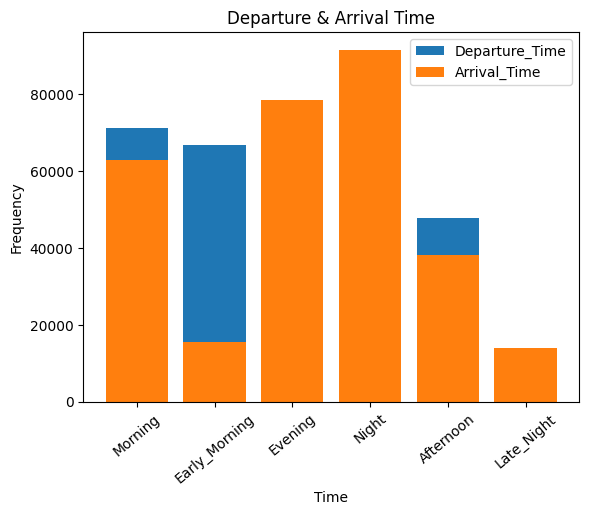

In [13]:
plt.bar(departure_time['departure'],departure_time['DCounts'],label='Departure_Time')
plt.bar(arrival_time['arrival'],arrival_time['ACounts'],label='Arrival_Time')
plt.title('Departure & Arrival Time')
plt.xlabel('Time')
plt.ylabel('Frequency')
plt.xticks(rotation=40)
plt.legend()
plt.show()


In [14]:
source_city=df['source_city'].value_counts().reset_index()
destination_city=df['destination_city'].value_counts().reset_index()

In [15]:
source_city.columns=['city','P_counts']
destination_city.columns=['city','P_counts']

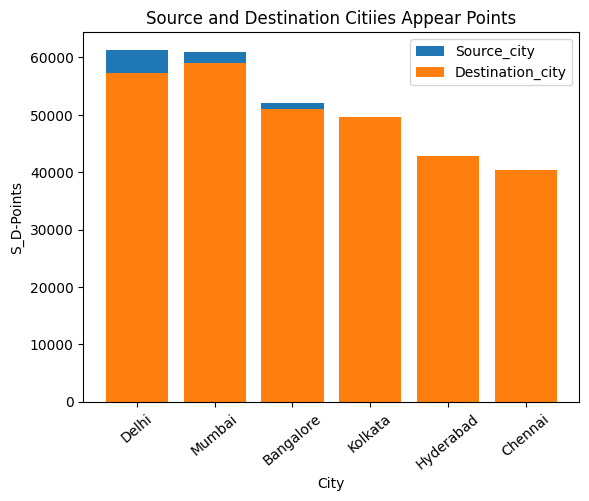

In [16]:
plt.bar(source_city['city'],source_city['P_counts'],label='Source_city')
plt.bar(destination_city['city'],destination_city['P_counts'],label='Destination_city')
plt.title('Source and Destination Citiies Appear Points')
plt.xlabel('City')
plt.ylabel('S_D-Points')
plt.xticks(rotation=40)
plt.legend()
plt.show()


In [17]:
variations_price=df.groupby('airline')['price'].mean().reset_index()

In [18]:
variations_price.columns=['Airline','Avg_price']

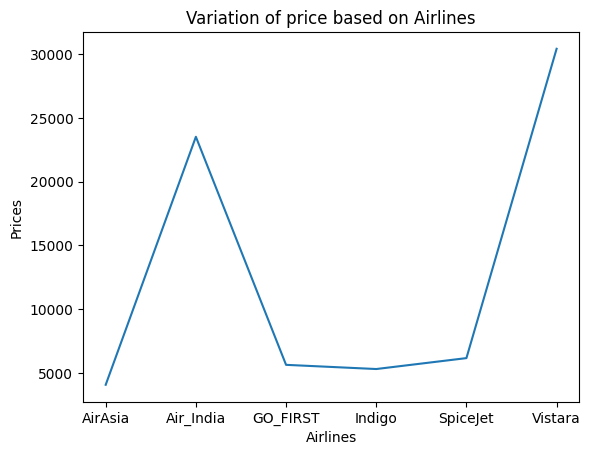

In [19]:
plt.plot(variations_price['Airline'],variations_price['Avg_price'])
plt.title('Variation of price based on Airlines')
plt.xlabel('Airlines')
plt.ylabel('Prices')
plt.show()

In [20]:
td=df.groupby('departure_time')['price'].mean().reset_index()
ad=df.groupby('arrival_time')['price'].mean().reset_index()

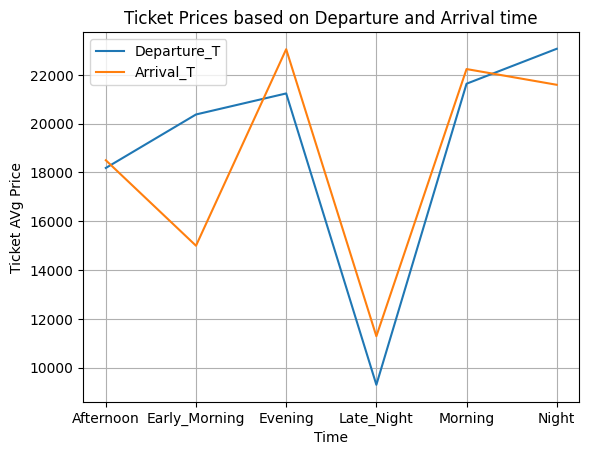

In [21]:
plt.plot(td['departure_time'],td['price'], label='Departure_T')
plt.plot(ad['arrival_time'],ad['price'], label='Arrival_T')
plt.title('Ticket Prices based on Departure and Arrival time')
plt.xlabel('Time')
plt.ylabel('Ticket AVg Price')
plt.legend()
plt.grid(True)
plt.show()

In [22]:
source_city=df.groupby('source_city')['price'].mean().reset_index()
destination_city=df.groupby('destination_city')['price'].mean().reset_index()

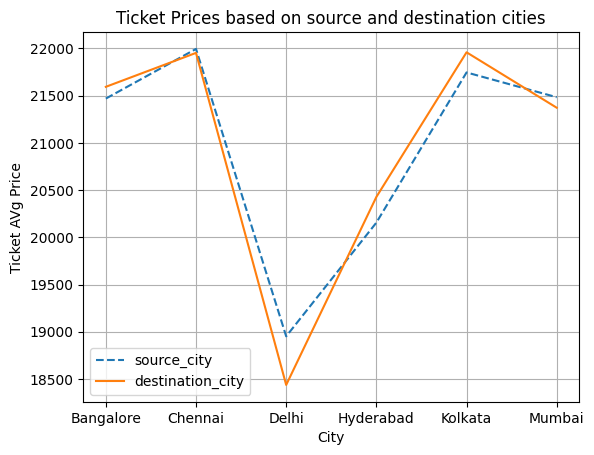

In [23]:
plt.plot(source_city['source_city'],source_city['price'], label='source_city',linestyle='--')
plt.plot(destination_city['destination_city'],destination_city['price'], label='destination_city')
plt.title('Ticket Prices based on source and destination cities')
plt.xlabel('City')
plt.ylabel('Ticket AVg Price')
plt.legend()
plt.grid(True)
plt.show()

In [24]:
daysBased=df.groupby('days_left')['price'].mean().reset_index()

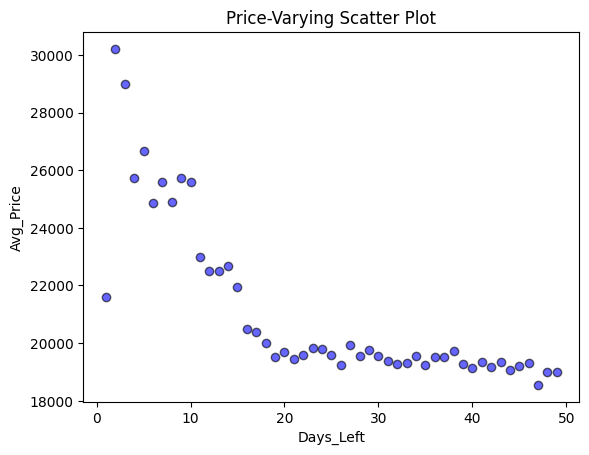

In [25]:
plt.scatter(daysBased['days_left'],daysBased['price'], 
           c='blue',
           alpha=0.6,
           edgecolors='black')

plt.title('Price-Varying Scatter Plot')
plt.xlabel('Days_Left')
plt.ylabel('Avg_Price')
plt.show()

In [26]:
classes=df.groupby('class')['price'].mean().reset_index()

In [27]:
classes

,class,price
0,Business,52540.081124
1,Economy,6572.342383


C:\Users\amand\AppData\Local\Temp\ipykernel_31316\1871161359.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


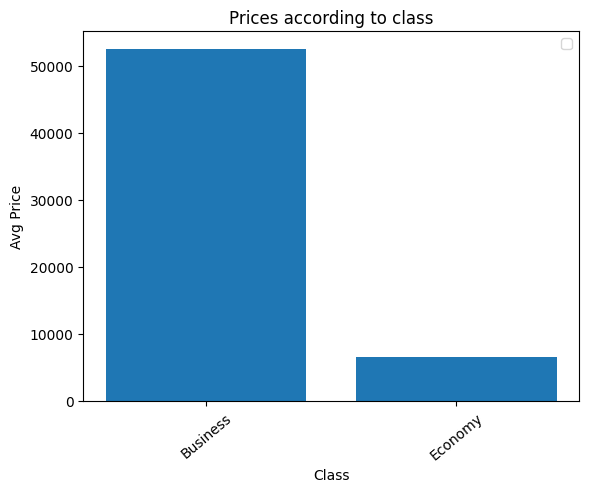

In [28]:
plt.bar(classes['class'],classes['price'])
plt.title('Prices according to class')
plt.xlabel('Class')
plt.ylabel('Avg Price')
plt.xticks(rotation=40)
plt.legend()
plt.show()


In [29]:
df

,airline,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...
300148,Vistara,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,Vistara,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,Vistara,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,Vistara,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585


In [30]:
x=df[df['airline']=='Vistara']

In [31]:
y=x[x['source_city']=='Delhi']
z=x[x['destination_city']=='Hyderabad']
a=x[x['class']=='Business']
avg=a.groupby('airline')['price'].mean().reset_index()
avg

,airline,price
0,Vistara,55477.027777


In [32]:
print("Average price for Vistara airlines from delho to hyderabad for a business class=\n",avg)

Average price for Vistara airlines from delho to hyderabad for a business class=
    airline         price
0  Vistara  55477.027777


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  object 
 1   source_city       300153 non-null  object 
 2   departure_time    300153 non-null  object 
 3   stops             300153 non-null  object 
 4   arrival_time      300153 non-null  object 
 5   destination_city  300153 non-null  object 
 6   class             300153 non-null  object 
 7   duration          300153 non-null  float64
 8   days_left         300153 non-null  int64  
 9   price             300153 non-null  int64  
dtypes: float64(1), int64(2), object(7)
memory usage: 22.9+ MB


In [34]:
numeric_features=['duration','days_left']
categorical_features=['airline','source_city','departure_time','stops','arrival_time','destination_city','class']

In [35]:
x=df.drop(columns=['price'])
y=df['price']

In [36]:
x

,airline,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left
0,SpiceJet,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1
1,SpiceJet,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1
2,AirAsia,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1
3,Vistara,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1
4,Vistara,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1
...,...,...,...,...,...,...,...,...,...
300148,Vistara,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49
300149,Vistara,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49
300150,Vistara,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49
300151,Vistara,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49


In [37]:
df.shape

(300153, 10)

In [38]:
from sklearn.model_selection import train_test_split,RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score,mean_squared_error
from xgboost import XGBRegressor
import joblib

In [39]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [40]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),  # Scale numerical features
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)  # Encode categoricals
    ],
    remainder='passthrough'  
)


In [41]:
model=Pipeline(steps=[
    ('Processing',preprocessor),
    ('regressor', XGBRegressor(
        tree_method='hist',  # Faster than 'exact'
        device='cpu',      
        n_jobs=-1, 
        n_estimators=100,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        early_stopping_rounds=50,
        eval_metric='rmse',
        random_state=42
    ))
])

In [43]:
preprocessor.fit(x_train)

ColumnTransformer(remainder='passthrough',
                  transformers=[('num', StandardScaler(),
                                 ['duration', 'days_left']),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['airline', 'source_city', 'departure_time',
                                  'stops', 'arrival_time', 'destination_city',
                                  'class'])])

In [44]:
model.fit(
    x_train, y_train,
    regressor__eval_set=[(preprocessor.transform(x_test), y_test)],#for validation set
    regressor__verbose=50
)

[0]	validation_0-rmse:21632.74754
[50]	validation_0-rmse:5074.78086
[99]	validation_0-rmse:4423.05652


Pipeline(steps=[('Processing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['duration', 'days_left']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['airline', 'source_city',
                                                   'departure_time', 'stops',
                                                   'arrival_time',
                                                   'destination_city',
                                                   'class'])])),
                ('regressor',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              c...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.05,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=6, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=100, n_jobs=-1,
                              num_parallel_tree=None, ...))])

In [45]:
y_pred=model.predict(x_test)

In [46]:
accuracy=r2_score(y_test,y_pred)

In [47]:
print(accuracy)

0.9620482921600342


In [48]:

y_train_pred = model.predict(x_train)
y_test_pred = model.predict(x_test)

# Evaluate
train_rmse = mean_squared_error(y_train, y_train_pred)
test_rmse = mean_squared_error(y_test, y_test_pred)

print(f"Train RMSE: {train_rmse:.2f}")
print(f"Test RMSE: {test_rmse:.2f}")


Train RMSE: 18872854.00
Test RMSE: 19563428.00


In [50]:
joblib.dump(model,'airline_ticket.joblib')

['airline_ticket.joblib']